In [40]:
import tensorflow as tf
from tensorflow import keras

from nn.rolypoly import dataset, model
from physics.hstar import gghzz, c6
from physics.simulation import msq
from physics.hzz import zpair, kinematics

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import hist

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [41]:
SEED=373485

BASE_SIZE=10000

OUTPUT_DIRS=['jobs/rolypoly/gpudev-three-MSE-bs32/coeff_1']#,'jobs/rolypoly/run-eight-MAE/coeff_2','jobs/rolypoly/run-eight-MAE/coeff_3','jobs/rolypoly/run-eight-MAE/coeff_4']
CONF_FILE='rolypoly-config.json'
SCALER_CONF='scaler.json'
SAMPLE_DIR='..'

COMPONENT = msq.Component.SBI

In [42]:
configs = []

for output_dir in OUTPUT_DIRS:
    with open(os.path.join(output_dir, CONF_FILE), 'r') as conf_file:
        configs.append(json.load(conf_file))

In [43]:
sample = gghzz.Process(COMPONENT, (1.5, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sbi.csv'), BASE_SIZE*1.2))

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)
bkg_nan_filter = msq.MSQFilter('msq_bkg_sm', value=np.nan)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZMasses(bounds1 = (70,115), bounds2 = (70,115))

angles = kinematics.AngularVariables()
four_lepton = kinematics.FourLeptonSystem()

events_training, events_validation = sample.events.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:int(configs[0]['num_events'])].shuffle(random_state=SEED)[:BASE_SIZE].split(training=0.5, validation=0.5)

In [44]:
c6_mod_train = c6.Modifier(baseline = msq.Component.SBI, events=events_training, c6_values = [-5,-1,0,1,5])
coeff_train = c6_mod_train.coefficients

c6_mod_val = c6.Modifier(baseline = msq.Component.SBI, events=events_validation, c6_values = [-5,-1,0,1,5])
coeff_val = c6_mod_val.coefficients

In [45]:
print(coeff_train, coeff_train.shape)

[[ 1.00000000e+00  4.38872942e-05 -9.27260440e-06 -1.27131970e-07
   3.88087065e-08]
 [ 1.00000000e+00 -1.00311728e-03  3.94086032e-04 -2.51965680e-06
   4.34143764e-07]
 [ 1.00000000e+00 -7.74944151e-04  1.48908718e-04 -1.91207356e-06
   2.04831467e-07]
 ...
 [ 1.00000000e+00 -1.01760985e-03  2.17286053e-04 -1.06845491e-05
   1.31179770e-06]
 [ 1.00000000e+00 -4.13888564e-04  7.05283629e-05 -1.47403718e-05
   1.70316705e-06]
 [ 1.00000000e+00  1.41625380e-05  1.35345016e-05 -1.26876041e-07
   2.53752081e-08]] (5000, 5)


In [46]:
kin_variables = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']
#kin_variables = ['p1_px', 'p1_py', 'p1_pz', 'p1_E', 
#                 'p2_px', 'p2_py', 'p2_pz', 'p2_E',
#                 'p3_px', 'p3_py', 'p3_pz', 'p3_E',
#                 'p4_px', 'p4_py', 'p4_pz', 'p4_E']

kinematics_training = events_training.kinematics[kin_variables].to_numpy()
kinematics_validation = events_validation.kinematics[kin_variables].to_numpy()

In [47]:
train_sets = [dataset.build_dataset(x_arr=kinematics_training, target=coeff_train[:,i], weights=events_training.probabilities) for i in range(1,coeff_train.shape[1])]
val_sets = [dataset.build_dataset(x_arr=kinematics_validation, target=coeff_val[:,i], weights=events_validation.probabilities) for i in range(1,coeff_val.shape[1])]

In [48]:
print(train_sets[0].shape)

(5000, 11)


In [49]:
scaler_configs = []

for output_dir in OUTPUT_DIRS:
    with open(os.path.join(output_dir, SCALER_CONF), 'r') as conf_file:
        scaler_configs.append(json.load(conf_file))

In [50]:
scalers = [MinMaxScaler() for _ in range(len(scaler_configs))]
for i in range(len(scalers)):
    scalers[i].min_ = scaler_configs[i]['scaler.min_']
    scalers[i].scale_ = scaler_configs[i]['scaler.scale_']

train_sets = [tf.concat([scalers[i].transform(train_sets[i][:,:-2]), train_sets[i][:,-2:]], axis=1) for i in range(len(scalers))]
val_sets = [tf.concat([scalers[i].transform(val_sets[i][:,:-2]), val_sets[i][:,-2:]], axis=1) for i in range(len(scalers))]

In [51]:
rolypoly_models = [model.load(os.path.join(OUTPUT_DIRS[i], 'checkpoint.model.tf')) for i in range(len(OUTPUT_DIRS))]

In [52]:
predictions_train = [rolypoly_models[i].predict(train_sets[i][:,:-2]) for i in range(len(OUTPUT_DIRS))]
predictions_val = [rolypoly_models[i].predict(val_sets[i][:,:-2]) for i in range(len(OUTPUT_DIRS))]

157/157 [==============================] - 0s 675us/step


In [53]:
print(tf.reduce_min(train_sets[0][:,-2]))

tf.Tensor(-0.009932005, shape=(), dtype=float32)


In [54]:
def generate_histograms(data_train, pred_train, data_val, pred_val, num_bins, bounds=None):
    if bounds is None:
        range_min = tf.minimum(tf.minimum(tf.reduce_min(data_train[:,-1]), tf.reduce_min(pred_train)), tf.reduce_min(pred_val))
        range_max = tf.maximum(tf.maximum(tf.reduce_max(data_train[:,-1]), tf.reduce_max(pred_train)), tf.reduce_max(pred_val))
    else:
        range_min = bounds[0]
        range_max = bounds[1]
    
    hist_true = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_true.fill(data_train[:,-2], weight=data_train[:,-1])

    hist_train = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_train.fill(tf.squeeze(pred_train, axis=1), weight=data_train[:,-1])

    hist_val = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_val.fill(tf.squeeze(pred_val, axis=1), weight=data_val[:,-1])

    return (hist_true.to_numpy(), hist_train.to_numpy(), hist_val.to_numpy())

In [55]:
def plot_histograms(histograms, color='r', xlim=(0.2,0.8)):
    fig = plt.figure(figsize=(7,6))

    plt.step(histograms[0][1][1:], histograms[0][0], color=color, linestyle='--', label=f'truth', alpha=0.6)
    plt.step(histograms[1][1][1:], histograms[1][0], color=color, label=f'training data', alpha=0.6)
    plt.scatter(histograms[2][1][1:], histograms[2][0], s=20, color=color, label=f'validation data', alpha=0.6)

    plt.xlabel('NN output []')
    plt.ylabel('Percentage of predictions []')
    plt.legend()
    plt.xlim(xlim[0],xlim[1])
    plt.yscale('log')
    #plt.xscale('log')

    plt.show()

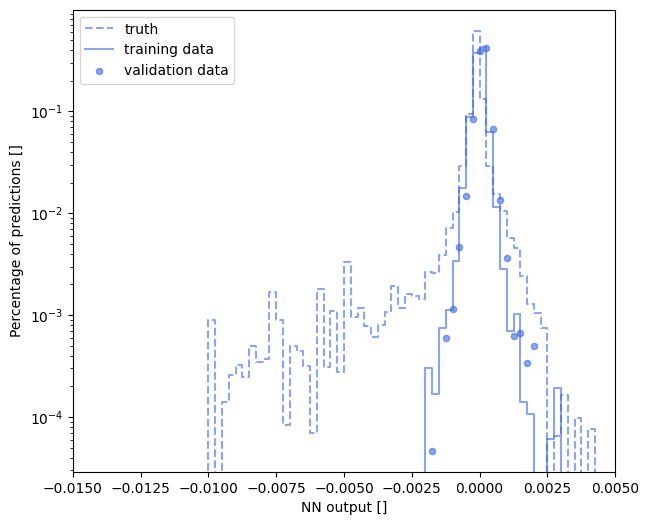

In [56]:
BINS = 80

coeff_index = 1

histograms_1 = generate_histograms(train_sets[0], predictions_train[0], val_sets[0], predictions_val[0], BINS, bounds=(-1.5e-2,5e-3))
#histograms_2 = generate_histograms(train_sets[1], predictions_train[1], val_sets[1], predictions_val[1], BINS, bounds=(-1e-3,1.5e-3))
#histograms_3 = generate_histograms(train_sets[2], predictions_train[2], val_sets[2], predictions_val[2], BINS, bounds=(-2e-5,1e-6))
#histograms_4 = generate_histograms(train_sets[3], predictions_train[3], val_sets[3], predictions_val[3], BINS, bounds=(-5e-7,5e-6))

plot_histograms(histograms_1, color='royalblue', xlim=(-1.5e-2,5e-3))

In [57]:
plot_histograms(histograms_2, color='gray', xlim=(-1e-3,1.5e-3))

NameError: name 'histograms_2' is not defined

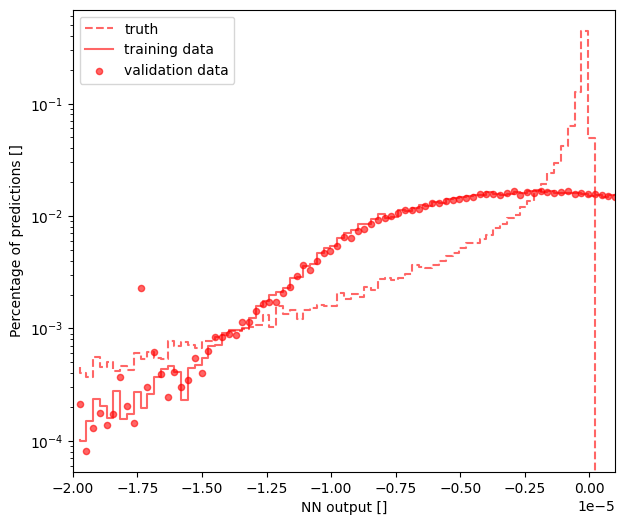

In [94]:
plot_histograms(histograms_3, color='red', xlim=(-2e-5,1e-6))

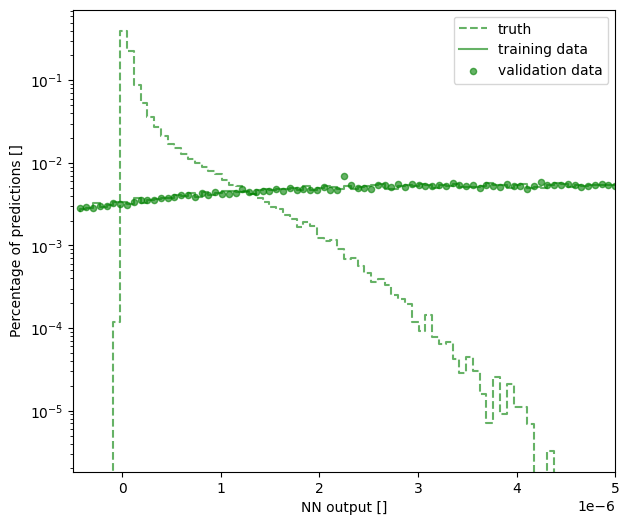

In [95]:
plot_histograms(histograms_4, color='green', xlim=(-5e-7,5e-6))

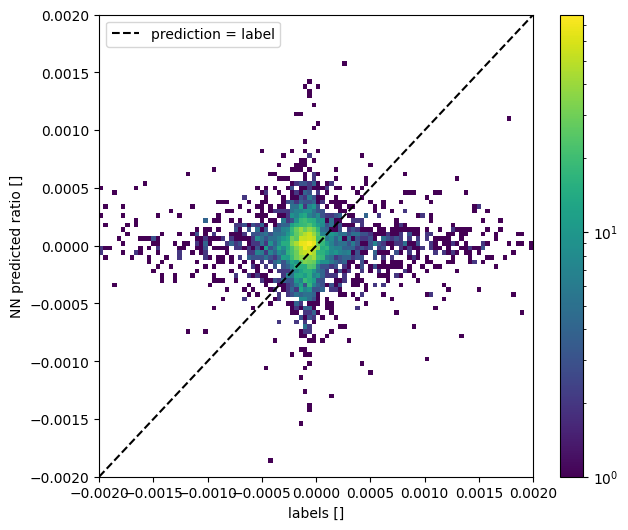

In [60]:
bounds = [-2e-3,2e-3]

i=0

fig, ax = plt.subplots(figsize=(7,6))

im = ax.hist2d(train_sets[i][:,-2], predictions_train[i].T[0], bins=100, range=[bounds,bounds], norm=LogNorm())
ax.plot(np.linspace(*bounds), np.linspace(*bounds), '--', color='k', label='prediction = label')

fig.colorbar(im[3], ax=ax)

plt.xlabel(f'labels []')
plt.ylabel(f'NN predicted ratio []')
plt.legend()

plt.show()

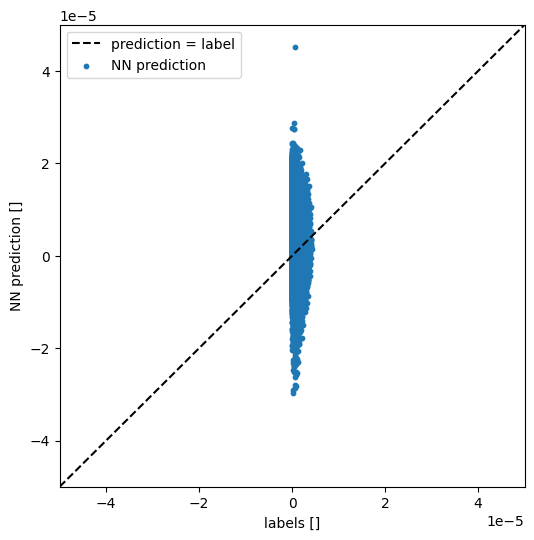

In [96]:
bounds = [[-2e-2, 6e-3],
          [-8e-3, 8e-3],
          [-15e-4, 15e-4],
          [-5e-5, 5e-5]]
i = 3
bounds = bounds[i]

fig = plt.figure(figsize=(6,6))


plt.plot(np.linspace(*bounds), np.linspace(*bounds), '--', color='k', label='prediction = label')
plt.scatter(train_sets[i][:,-2], predictions_train[i], s=10, label='NN prediction')

plt.xlim(*bounds)
plt.ylim(*bounds)
plt.xlabel(f'labels []')
plt.ylabel(f'NN prediction []')
plt.legend()

plt.show()

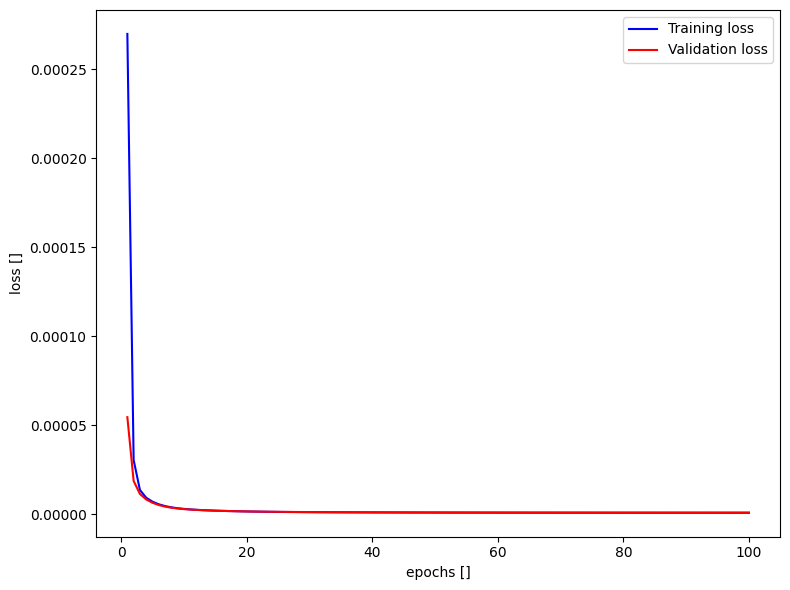

In [61]:
hist_prm = ''

i=0

with open(os.path.join(OUTPUT_DIRS[i], 'history.txt'), 'r') as hist_file:
    hist_prm = hist_file.readlines()

hist_prm = [ np.array(el.replace('[','').replace(']','').replace(' ','').split(','), dtype=float) for el in hist_prm[0].split('][')]

t_loss_prm = np.array(hist_prm[0])
v_loss_prm = np.array(hist_prm[1])

epochs = range(1,t_loss_prm.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss_prm, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss_prm, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()

In [98]:
c6_values = [-20,-10,0,10,20]

pred_coeff_train = np.ones_like(predictions_train[0])
predictions_train_ = np.squeeze(np.array(predictions_train), axis=2).T
pred_coeff_train = np.append(pred_coeff_train, predictions_train_, axis=1)

pred_coeff_val = np.ones_like(predictions_val[0])
predictions_val_ = np.squeeze(np.array(predictions_val), axis=2).T
pred_coeff_val = np.append(pred_coeff_val, predictions_val_, axis=1)

In [99]:
c6_mod_train.coefficients = pred_coeff_train
c6_wt_train, c6_pb_train = c6_mod_train.modify(c6_values)

ratios_pred_train = [c6_pb_train[:,i]/np.array(events_training.probabilities) for i in range(len(c6_values))]

In [100]:
c6_mod_val.coefficients = pred_coeff_val
c6_wt_val, c6_pb_val = c6_mod_val.modify(c6_values)

ratios_pred_val = [c6_pb_val[:,i]/np.array(events_validation.probabilities) for i in range(len(c6_values))]

In [101]:
c6_mod_train.coefficients = coeff_train
c6_wt_train_true, c6_pb_train_true = c6_mod_train.modify(c6_values)

ratios_true = [c6_pb_train_true[:,i]/np.array(events_training.probabilities) for i in range(len(c6_values))]

In [102]:
def generate_histograms_2(quantity_train, quantity_val, truth, pred_train, pred_val, events_training, events_validation, num_bins, range=None):
    range_min = tf.minimum(tf.minimum(tf.reduce_min(truth), tf.reduce_min(pred_train)), tf.reduce_min(pred_val))
    range_max = tf.maximum(tf.maximum(tf.reduce_max(truth), tf.reduce_max(pred_train)), tf.reduce_max(pred_val))

    if range is not None:
        range_min = range[0]
        range_max = range[1]

    hist_true = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_true.fill(quantity_train, weight=truth*events_training.probabilities)

    hist_train = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_train.fill(quantity_train, weight=pred_train*events_training.probabilities)

    hist_val = hist.Hist(hist.axis.Regular(num_bins, range_min, range_max, name='x', label='NN output []'))
    hist_val.fill(quantity_val, weight=pred_val*events_validation.probabilities)

    return (hist_true.to_numpy(), hist_train.to_numpy(), hist_val.to_numpy())

In [103]:
def plot_histograms_2(histograms, color='r', xlim=(0.2,0.8), factor=1):
    fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

    ax1.set_xticklabels([])

    ax1.step(histograms[0][1][1:], histograms[0][0], color=color, linestyle='--', label=f'truth', alpha=0.6)
    ax1.step(histograms[1][1][1:], histograms[1][0], color=color, label=f'training data', alpha=0.6)
    #ax1.scatter(histograms[2][1][1:]-factor/len(histograms[2][1][1:]), histograms[2][0], s=20, color=color, label=f'validation data', alpha=0.6)

    ax1.set_ylabel('Percentage of predictions []')
    ax1.legend()
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_yscale('log')

    ax2.step(histograms[0][1][1:], np.ones_like(histograms[0][1][1:]), color=color, linestyle='--', label=f'truth', alpha=0.6)
    ax2.step(histograms[1][1][1:], histograms[1][0]/histograms[0][0], color=color, label=f'training data', alpha=0.6)
    #ax2.scatter(histograms[2][1][1:]-factor/len(histograms[2][1][1:]), histograms[2][0]/histograms[0][0], s=20, color=color, label=f'validation data', alpha=0.6)
    
    ax2.set_xlabel(u'$m_{4\ell}$ [GeV]')
    ax2.set_ylabel('R []')
    ax2.set_xlim(xlim[0],xlim[1])
    #ax2.set_ylim(0.85,1.15)

    plt.show()

/tmp/ipykernel_114854/4102073621.py:16: RuntimeWarning: invalid value encountered in divide
  ax2.step(histograms[1][1][1:], histograms[1][0]/histograms[0][0], color=color, label=f'training data', alpha=0.6)


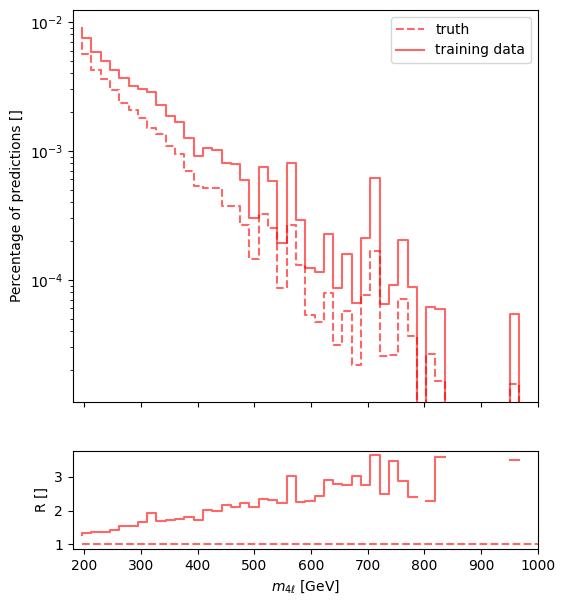

In [104]:
BINS=50

histo_range=(180,1000)

c6 = -10

i = c6_values.index(c6)

histograms_5 = generate_histograms_2(kinematics_training[:,-2], kinematics_validation[:,-2], ratios_true[i], ratios_pred_train[i], ratios_pred_val[i], events_training, events_validation, num_bins=BINS, range=histo_range)

plot_histograms_2(histograms_5, color='red', xlim=histo_range)

In [105]:
def plot_histograms_3(histograms, c6_values, colors, xlim=(0.2,0.8), factor=1):
    fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

    ax1.set_xticklabels([])

    zero_i = c6_values.index(0)

    for i in range(len(colors)):
        ax1.step(histograms[i][0][1][1:], histograms[i][0][0], color=colors[i], linestyle='--', label=f'truth (c6={c6_values[i]})', alpha=0.6)
        ax1.step(histograms[i][1][1][1:], histograms[i][1][0], color=colors[i], label=f'training data (c6={c6_values[i]})', alpha=0.6)
        #ax1.scatter(histograms[i][2][1][1:]-factor/len(histograms[i][2][1][1:]), histograms[i][2][0], s=20, color=colors[i], label=f'validation data (c6={c6_values[i]})', alpha=0.6)

    ax1.set_ylabel('Percentage of predictions []')
    ax1.legend()
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_yscale('log')

    for i in range(len(colors)):
        ax2.step(histograms[i][0][1][1:], histograms[i][0][0]/histograms[zero_i][0][0], color=colors[i], linestyle='--', label=f'truth (c6={c6_values[i]})', alpha=0.6)
        ax2.step(histograms[i][1][1][1:], histograms[i][1][0]/histograms[zero_i][0][0], color=colors[i], label=f'training data (c6={c6_values[i]})', alpha=0.6)
        #ax2.scatter(histograms[i][2][1][1:]-factor/len(histograms[i][2][1][1:]), histograms[i][2][0]/histograms[zero_i][0][0], s=20, color=colors[i], label=f'validation data (c6={c6_values[i]})', alpha=0.6)
        
    ax2.set_xlabel(u'$m_{4\ell}$ [GeV]')
    ax2.set_ylabel('R []')
    ax2.set_xlim(xlim[0],xlim[1])
    ax2.set_ylim(0.97,1.02)

    plt.show()

In [106]:
BINS=50

histo_range=(180,1000)

c6 = [-10, 0, 10]
colors = ['limegreen', 'grey', 'royalblue']

indices = [c6_values.index(c6_val) for c6_val in c6]

histograms_6 = [generate_histograms_2(kin_vars_train[:,-2], kin_vars_val[:,-2], ratios_true[i], ratios_pred_train[i], ratios_pred_val[i], sample_train, sample_val, num_bins=BINS, range=histo_range) for i in indices]

plot_histograms_3(histograms_6, c6_values=c6, colors=colors, xlim=histo_range)

NameError: name 'kin_vars_train' is not defined

In [392]:
JOB_ID = 14586068
i = 1

JOB_OUT_FILE = os.path.join(OUTPUT_DIRS[i], 'logs', 'job.out.' + str(JOB_ID))

import re

with open(JOB_OUT_FILE, 'r') as log_file:
    logs = ''.join(log_file.readlines())

t_loss = np.array(re.findall("\ loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)
v_loss = np.array(re.findall("\ val_loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)

epochs = range(1,t_loss.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'jobs/rolypoly/run-five-MAE/coeff_2/logs/job.out.14586068'

In [407]:
bce = tf.keras.losses.BinaryCrossentropy()
y_pred = np.array([0.73, 0.234, 0.345])
y_true = np.array([0.75, 0.225, 0.333])

print(bce(y_true, y_pred))
print(np.sum(-y_true*np.log(y_pred)-(1-y_true)*np.log(1-y_pred))/3)

tf.Tensor(0.5777869766768555, shape=(), dtype=float64)
0.5777871736817977
